Saving Housing.csv to Housing (3).csv

Dataset Loaded Successfully!
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Missing Values:
 price        

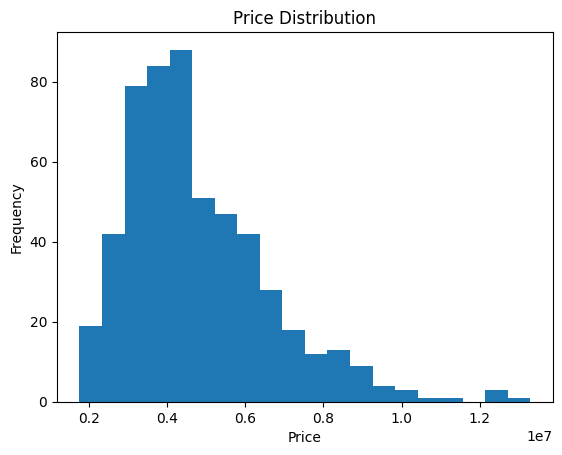

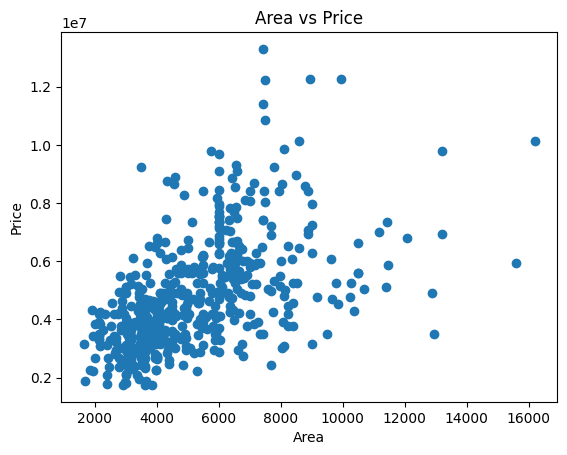

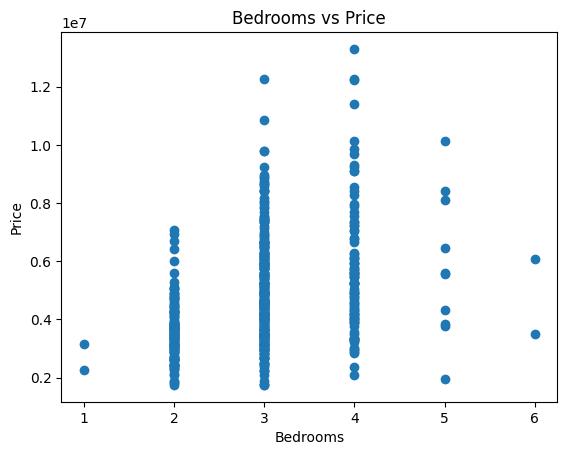


--- DATA INSIGHTS ---
Average Price: 4766729.247706422
Maximum Price: 13300000
Minimum Price: 1750000
Average Area: 5150.54128440367
Correlation (Area vs Price): 0.5359973457780797

--- Linear Regression ---
MAE: 1265275.6699454375
R2 Score: 0.4559299118872445

--- Decision Tree ---
MAE: 1261903.0581039754
R2 Score: 0.3395549292202551

--- MODEL COMPARISON ---
Linear Regression performs better.

Feature Importance (Linear Regression):
     Feature    Importance
0       area  3.454666e+02
1   bedrooms  3.601977e+05
2  bathrooms  1.422320e+06

Sample Deal Evaluation:
      price  Predicted_Price    Deal_Tag
0  13300000     6.908277e+06  Overpriced
1  12250000     1.028494e+07  Overpriced
2  12250000     7.425565e+06  Overpriced
3  12215000     6.935915e+06  Overpriced
4  11410000     5.485958e+06  Overpriced

--- USER PREDICTION SYSTEM ---
Predicted Price: 4675650.78603028
This is a moderate-value property.

Project Completed Successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from google.colab import files
uploaded = files.upload()

data = pd.read_csv("Housing.csv")

print("\nDataset Loaded Successfully!")
print(data.head())

print("\nMissing Values:\n", data.isnull().sum())

data = data.fillna(data.mean(numeric_only=True))

plt.figure()
plt.hist(data['price'], bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Area vs Price
plt.figure()
plt.scatter(data['area'], data['price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

# Bedrooms vs Price
plt.figure()
plt.scatter(data['bedrooms'], data['price'])
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Bedrooms vs Price")
plt.show()

print("\n--- DATA INSIGHTS ---")

print("Average Price:", data['price'].mean())
print("Maximum Price:", data['price'].max())
print("Minimum Price:", data['price'].min())

print("Average Area:", data['area'].mean())

print("Correlation (Area vs Price):", data['area'].corr(data['price']))

X = data[['area', 'bedrooms', 'bathrooms']]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\n--- Linear Regression ---")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))

dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\n--- Decision Tree ---")
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("R2 Score:", r2_score(y_test, dt_pred))

print("\n--- MODEL COMPARISON ---")

if r2_score(y_test, lr_pred) > r2_score(y_test, dt_pred):
    print("Linear Regression performs better.")
    best_model = lr_model
else:
    print("Decision Tree performs better.")
    best_model = dt_model

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lr_model.coef_
})

print("\nFeature Importance (Linear Regression):")
print(importance)

data['Predicted_Price'] = best_model.predict(X)

data['Deal_Tag'] = data.apply(
    lambda x: "Good Deal" if x['price'] <= x['Predicted_Price'] else "Overpriced",
    axis=1
)

print("\nSample Deal Evaluation:")
print(data[['price', 'Predicted_Price', 'Deal_Tag']].head())

print("\n--- USER PREDICTION SYSTEM ---")

# Example input (you can change)
new_house = [[2000, 3, 2]]

predicted_price = best_model.predict(new_house)

print("Predicted Price:", predicted_price[0])

if predicted_price[0] > 5000000:
    print("This is a high-value property.")
else:
    print("This is a moderate-value property.")

data.to_csv("housing_output_results.csv", index=False)

print("\nProject Completed Successfully!")

In [6]:
print("\n===== INTERACTIVE HOUSE PRICE PREDICTION =====")

try:
    area = float(input("Enter Area of house: "))
    bedrooms = int(input("Enter Number of Bedrooms: "))
    bathrooms = int(input("Enter Number of Bathrooms: "))

    user_input = [[area, bedrooms, bathrooms]]

    predicted_price = best_model.predict(user_input)[0]

    print("\n--- RESULT ---")
    print("Predicted Price:", predicted_price)

    # Decision logic
    if predicted_price > 8000000:
        print("Category: Expensive Property 💰")
    elif predicted_price > 4000000:
        print("Category: Mid-Range Property 🏡")
    else:
        print("Category: Budget Property 👍")

except:
    print("Invalid input. Please enter correct values.")


===== INTERACTIVE HOUSE PRICE PREDICTION =====
Enter Area of house: 15.5
Enter Number of Bedrooms: 2
Enter Number of Bathrooms: 1

--- RESULT ---
Predicted Price: 2207555.0696014287
Category: Budget Property 👍


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
